In [1]:
import numpy as np
from typing import Optional, Tuple
from math import ceil, floor, gcd, sqrt
import matplotlib.pyplot as plt
from utils import dense, case0, case0_rec, g2k
from matplotlib.colors import LinearSegmentedColormap

In [2]:
def get_dense_batch_position(m: int, n: int, k:int, b:int, N1:int, core_id: int, round_id: int) -> Optional[Tuple[int, int, int]]:

    k = min(k, b*N1*m, b*n)
    R = max(ceil(b*n*N1/k), ceil(n/m), N1)
    
    if core_id < 1 or core_id > k or round_id < 1 or round_id > R*m:
        return None
    

    ID = (core_id - 1) * R + ceil(round_id/m)
    local_id = round_id%m or m
    

    if ID > N1*n*b:
        return None
    
    N = b*N1
    b_id = ID % N or N
    b_id = ceil(b_id/N1)
    y = ceil(ID/N)
    w = ID % N1 or N1

    
    g = gcd(N, R)
    t1 = R // g
    #实际不需要计算t2也可以 因为t2*R就是t1*b
    t2 = N // g
    
    t1_new = t1 * m
    y1 = y%t1_new or t1_new
    offset = ceil(y1/t1) 

    if t1_new < n:
        n1 = (n % t1_new) or t1_new
        if y <= n - n1:
            delta = ceil(y / t1_new)
            ID += delta
            if ID > (delta-1) * t2 * m * R + offset * t2 * R:
                ID -= t2 * R
                
            #20251224
            b_id = ID % N or N
            b_id = ceil(b_id/N1)    
            
            w = ID % N1 or N1
            y = ceil(ID/N)

  
    x = local_id + offset - 1
    if x>m:
        x -= m

    return (w+(b_id-1)*N1, x, y)

In [3]:
def calc_pos(k, m, n, j, r):
    # 1. special case
    if k >= (n // 2) + 1:
        return case0_rec(k, m, n, j, r)

    ell = n % k
    t1 = n // (2 * k) 
    t2 = 0
    t3 = (n // k) % 2

    offset = 0
    rm = 0

    # 2. 2k-block groups
    bound1 = (2 * m + 1) * t1 - 2 * k * t1 * t1
    if r <= bound1:
        # solve for group index i
        disc = (2 * m + 1)**2 - 8 * k * r
        i = ceil(((2 * m + 1) - sqrt(disc)) / (4 * k))
        rm = (2 * m + 1) * (i - 1) - 2 * k * (i - 1) * (i - 1)
        offset = 2 * k * (i - 1)
        L1 = m - 2 * k * (i - 1)
        a = r - rm
        return g2k(k, j, a, L1, offset)
    else:
        rm = bound1
        offset = 2 * k * t1

    # 3. remaining block
    rem = t3 * k + ell
    if rem > 0:
        L1 = m - n + rem
        a = r - rm
        if t3 == 0 and j <= rem:
            y = offset + j
            x = y + a - 1
            return (x, y)
        elif t3 == 1:
            res = case0_rec(k, L1, L1, j, a)
            if res is None:
                return None
            x1, y1 = res
            shift = 2 * k * t1 + 3 * k * t2
            return (x1 + shift, y1 + shift)
        else:
            return None

    # nothing to process
    return None

In [4]:
def calc_pos_batch_base(k, m, n, b, N1, j, r):
    # 1. b1, b2, rm1
    b1 = b // k
    b2 = b % k 
    delta = m - n
    size_tri = n * (m + delta + 1) // 2
    size_tri_group = size_tri * N1
    rm1 = b1 * size_tri_group

    # --- 第一段：完整梯形 ---
    if r <= rm1:
         
        a = r % size_tri_group or size_tri_group
        N1_id = ceil(a/size_tri)
        a = a % size_tri or size_tri
        b_id = k * (ceil(r / size_tri_group)-1) + j
        
        n1 = n//2*2
        L = 2 * m- n1 + 1
        rm_local = (n1 * L)//2
      
        if a <= rm_local:
            y = ceil(a/L)  
            r1 = a%L or L
            x = r1 + y - 1
            if x>m:
                x,y = 2*m + 1 -x, n1 + 1 - y
        else:
            a1 = a - rm_local
            y = n
            x = a1 - 1 + y 
                               
#         w=((w - 1) % b1) * k + (w - 1) // b1 + 1 #batch交错
# #         # w = ((y - 1 + (w - 1)) % (b1*k)) + 1   #b1*k个batch列交错
#         w = ((w - 1) // k) * k + ((y - 1+ (w - 1)) % k) + 1 #b1组，每组k个batch行交错   
        b_id = ((b_id - 1) // k) * k + ((y - 1+ (b_id - 1)) % k) + 1 #符合直觉
        w = (b_id - 1) * N1 + N1_id
  
    
        return (w, x, y)

    # 2. 拼成b2//2组batch 1～N1对应位置的两个batch拼在一起
    t    = n // k
    ell  = n % k
    a2   = r - rm1
    half = b2 // 2
    rm2  = (2*m - t*k + 1) * t * half * N1
    if 1 <= a2 <= rm2:
        # 调用 dense 子块
        (w_sub, x_sub, y_sub) = get_dense_batch_position(2*m - t*k + 1, t*k, k, half, N1, j, a2)
        # 新增范围检查
        max_x = 2*m - t*k + 1
        max_y = t*k
        max_w = half * N1
        if 1 <= x_sub <= max_x and 1 <= y_sub <= max_y and 1 <= w_sub <= max_w:   
            # 计算映射
            b_id = ceil(w_sub/N1)
            N1_id = w_sub% N1 or N1
            if x_sub - y_sub <= m - t*k:
                b_id = 2 * b_id - 1
                x = m + 1 - x_sub
                y = t*k + 1 - y_sub
            else:
                b_id = 2 * b_id
                x = x_sub - m + t*k - 1
                y = y_sub
                
            w = b1 * k * N1 + (b_id - 1) * N1 + N1_id
            
            return (w, x, y)
        else:
            return None
        
        
    # 3. 剩余分两种：b2 mod 2 == 1 或 else
    a3 = r - rm1 - rm2
    if b2 % 2 == 1:
        # 奇数 b2
        t1 = n // (2 * k) 
        t3 = t % 2
        
        if t3 == 1:
            m1 = m - t1*2*k
            rm3 = (m + m1 + 1) * t1
            if ell == 0:
                rm3 += m1
            else:
                rm3 += max(m1,2*m1-2*k+1)
            
            if 1 <= a3 <= rm3 * N1:
                N1_id = ceil(a3/rm3)
                a3 = a3%rm3 or rm3
                res = calc_pos(k, m, n, j, a3)
                # 用 isinstance 检查并拆包：
                if isinstance(res, tuple) and len(res) == 2:
                    coord = res[1] if isinstance(res[1], tuple) else res
                    x, y = coord
                    # 消费 b 和 b2：
                    # （如果后续逻辑还需要 b、b2，请在此做 b-=1, b2-=1）
                    return ((b-1) * N1 + N1_id, x, y)
                else:
                    return None
            b, b2=b-1, b2-1
            
        else:
            rm3 = (2*m - t*k + 1) * t // 2
            if 1 <= a3 <= rm3 * N1:
                N1_id = ceil(a3/rm3)
                a3 = a3%rm3 or rm3
                res = calc_pos(k, m, t*k, j, a3)
                if isinstance(res, tuple) and len(res) == 2:
                    coord = res[1] if isinstance(res[1], tuple) else res
                    x, y = coord
                    return ((b-1) * N1 + N1_id, x, y)
                else:
                    return None
    else:
        rm3=0
       
    
    
    # 4. 零碎余数 ℓ 部分

    a4    = a3 - rm3 * N1
    
    N1_id = a4%N1 or N1
    a4 = ceil(a4/N1)
    
    p     = ceil(ell / 2)
    ell1  = ell + 1 - (ell % 2)
    block = (b2 * p) // k
    res0  = (b2 * p) % k

    # 情况 A
    if a4 > block * (ell1 + 2 * delta) and res0 <= floor(k/2):
        offs = a4 - block * (ell1 + 2 * delta)
        # 前 res0 cores
        if 1 <= j <= res0:
            limit = floor((res0 - j) / b2) + ceil(ell1 / 2) + delta
            if offs <= limit:
                w = (k*floor((a4-1)/(ell1+2*delta)) + j) % b2 or b2
                y = p - floor((res0 - j) / b2)
                x = y + offs - 1
                if 1 <= y <= ell and y <= x <= ell + delta:
                    w = (w-1) * N1 + N1_id + b1*k*N1
                    return (w, x + t*k, y + t*k)
        # 后 res0 cores
        if k - res0 + 1 <= j <= k:
            idx = j - (k - res0 + 1)
            limit = floor((ell1 - 1) / 2) - floor(idx / b2) + delta
            if offs <= limit:
                w = (k*floor((a4-1)/(ell1+2*delta)) + k + 1 - j) % b2 or b2
                y = p + 1 + floor(idx / b2)
                x = y + offs - 1
                if 1 <= y <= ell and y <= x <= ell + delta:
                    w = (w-1) * N1 + N1_id + b1*k*N1
                    return (w, x + t*k, y + t*k)
        return None
    
    else:
        # 情况 B
        w = (k*floor((a4-1)/(ell1+2*delta)) + j) % b2 or b2
        g = ceil((k*floor((a4-1)/(ell1+2*delta)) + j) / b2)
        if 1 <= g <= p:
            a5 = a4 % (ell1 +2*delta) or (ell1 +2*delta)
            if g % 2 == 1:
                if a5 <= ell - g + 1 + delta:
                    x0, y0 = g + a5 - 1, g
                else:
                    x0 = 2*ell + 2*delta + 2 - g - a5
                    y0 = ell + 1 + (ell % 2) - g
            else:
                if a5 >= g + 1 + delta - (ell % 2):
                    x0 = g + ell + 2*delta + 1 - (ell % 2) - a5
                    y0 = g
                else:
                    x0 = a5 + ell - g + (ell % 2)
                    y0 = ell + 1 + (ell % 2) - g
            if 1 <= y0 <= ell and y0 <= x0 <= ell + delta:
                w = (w-1) * N1 + N1_id + b1*k*N1
                return (w, x0 + t*k, y0 + t*k)

    return None

In [5]:
def test_calc_batch(k, m, n, b, N1):
    
    size_tri1 = n * m - n * (n - 1) // 2
    b1, b2 =b//k, b%k
    rm1 = b1 * size_tri1
    
    t, ell = n // k, n%k
    t1 = n // (2 * k) 
    t3 = t % 2
    
    n1 = t * k
    half = b2 // 2
    rm2  = (2*m - n1 + 1) * t * half
      
    rm3 = 0
    if b2%2==1:
        if t3 == 1:
            m1 = m - t1*2*k
            rm3 = (m + m1 + 1) * t1
            if ell == 0:
                rm3 += m1
            else:
                rm3 += max(m1,2*m1-2*k+1)
            b2 = b2 - 1
        else:
            rm3 = (2*m - n1 + 1) * t // 2
    
    if ell%2 == 0:
        ell1 = ell//2
        L = 2 * (m - n) + ell + 1
    else:
        ell1 = ell//2+1
        L = 2 * (m - n) + ell
    
    rm4 = ceil(ell1*b2/k) * L
    
    print('rm1, rm2, rm3, rm4 : ',rm1,rm2,rm3,rm4)
    r_upper = rm1 + rm2 + rm3 + rm4
    
    r_upper *= N1
    print('r_upper = sum(rm) * N1 : ',r_upper)
    
    mapping = []
    
    for j in range(1, k + 1):
        for r in range(1, r_upper + 1):
            res = calc_pos_batch_base(k, m, n, b, N1, j, r)
            if isinstance(res, tuple) and len(res) == 3:
                w, x, y = res
                if 1 <= x <= m and 1 <= y <= n and x - y>=min(m-n,0):
                    mapping.append((w, j, r, x, y))
                    
    
    for w in range(1, b * N1 + 1):
        rounds_mat = np.zeros((m, n), dtype=int)
        core_mat   = np.zeros((m, n), dtype=int)
        r_max = 0

        # 填充
        for (ww, j, r, x, y) in mapping:
            if ww == w:
                rounds_mat[x-1, y-1] = r
                core_mat[x-1, y-1]   = j
                r_max = max(r_max, r)

        # 替换：只显示有值的 core_mat 格子
        core_masked = np.ma.array(core_mat, mask=(core_mat == 0))

#         fig, ax = plt.subplots(figsize=(3, 3 * m / n))
        cell_px = 36        # 每个格子大约 36 像素（可改 30~48）
        dpi     = 200       # 更高的 DPI 保证清晰
        width_in  = n * cell_px / dpi
        height_in = m * cell_px / dpi

        fig, ax = plt.subplots(figsize=(width_in, height_in), dpi=dpi)
#         cmap = plt.get_cmap('tab20', k)
        # 组合多个 colormap 获取更多基础颜色
        cmap1 = plt.get_cmap('tab20', 20)
        cmap2 = plt.get_cmap('tab20b', 20)
        cmap3 = plt.get_cmap('tab20c', 20)

        # 合并颜色列表并截取前32种
        all_colors = list(cmap1.colors) + list(cmap2.colors) + list(cmap3.colors)
        selected_colors = all_colors[:32]  # 只选取前32种颜色

        # 创建自定义 colormap
        cmap = LinearSegmentedColormap.from_list('custom_32', selected_colors)
        ax.imshow(core_masked, origin='upper', cmap=cmap, vmin=1, vmax=k, aspect='auto')

        # 网格线
        ax.set_xticks(np.arange(n+1)-0.5, minor=True)
        ax.set_yticks(np.arange(m+1)-0.5, minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
        ax.tick_params(which='minor', length=0)
        
        # 调整坐标轴数字大小
        ax.tick_params(axis='both', which='major', labelsize=6)

        # 主刻度与标签
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(m))
        ax.set_xticklabels(np.arange(1, n+1))
        ax.set_yticklabels(np.arange(1, m+1))

        # 只在有值的位置添加轮次文本且调整字体大小
        for i in range(m):
            for col in range(n):
                if rounds_mat[i, col] > 0:
                    ax.text(col, i, f"{rounds_mat[i, col]}", ha='center', va='center', fontsize=5, color='white')

        ax.set_title(f"k={k}, m={m}, n={n}, b={b}, N1={N1}, batch={w}")
        ax.set_xlabel("y (column)")
        ax.set_ylabel("x (row)")
        plt.tight_layout()
        plt.show()


In [6]:
# # 运行示例
# m=32
# n=32
# k=32
# b=1
# N1 = 8
# test_calc_batch(k, m, n,b ,N1)

rm1, rm2, rm3, rm4 :  0 0 22 0
r_upper = sum(rm) * N1 :  22


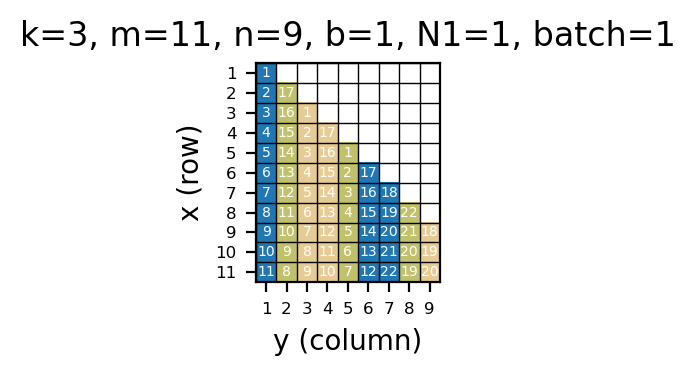

In [7]:
# 运行示例
m=11
n=9
k=3
b=1
N1 = 1
test_calc_batch(k, m, n,b ,N1)

In [8]:
# # 运行示例
# m=8
# n=8
# k= 3
# b = 2
# N1 = 4
# test_calc_batch(k, m, n,b, N1)

rm1, rm2, rm3, rm4 :  150 0 0 0
r_upper = sum(rm) * N1 :  300


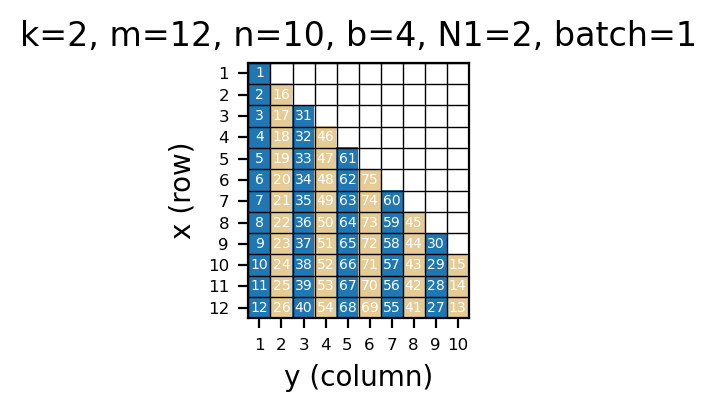

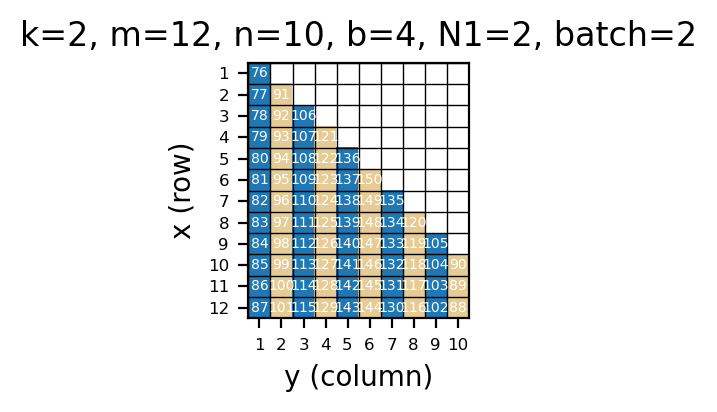

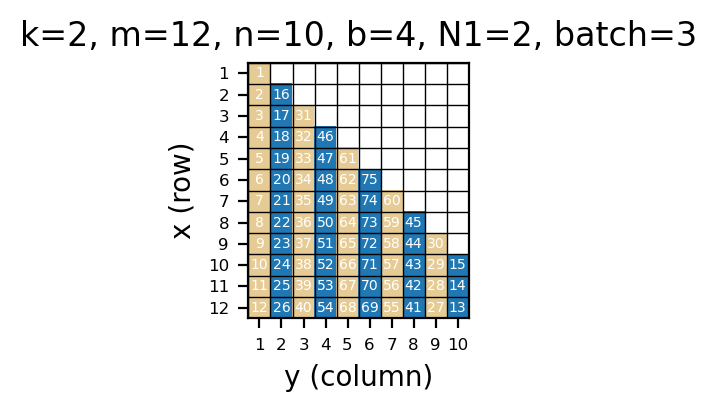

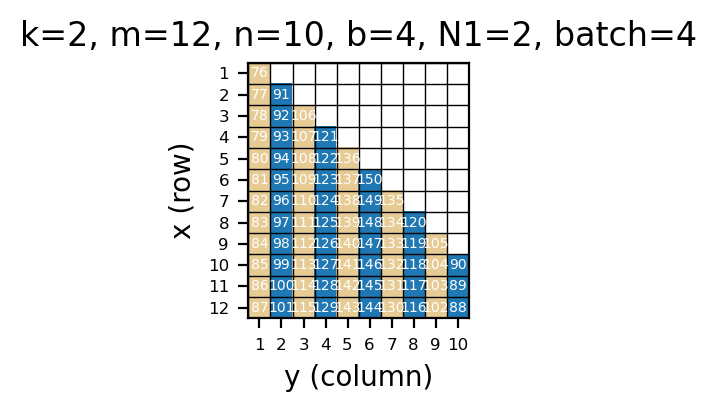

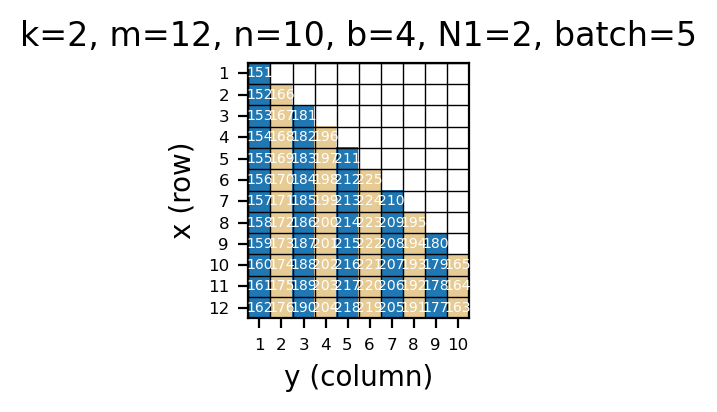

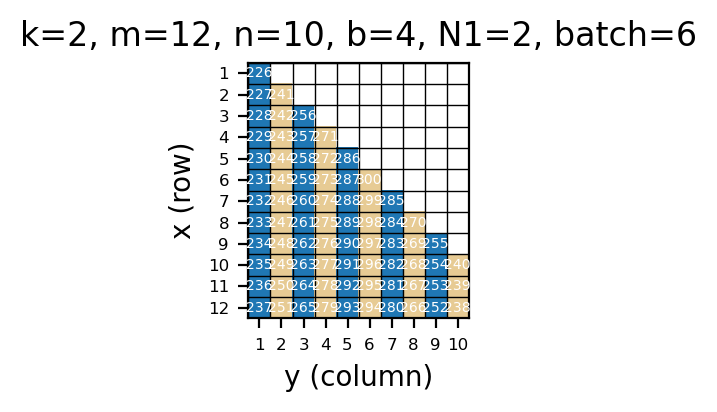

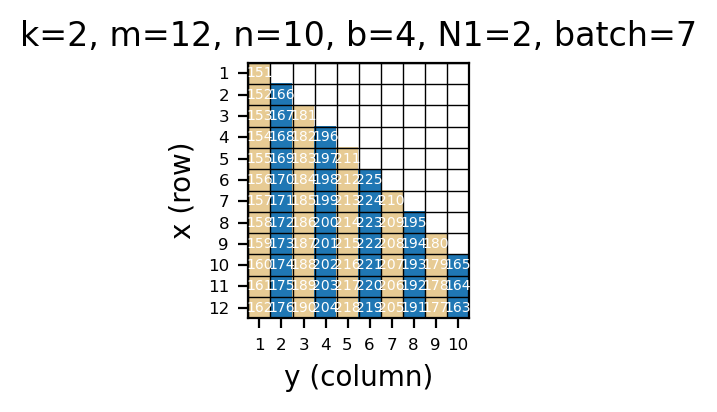

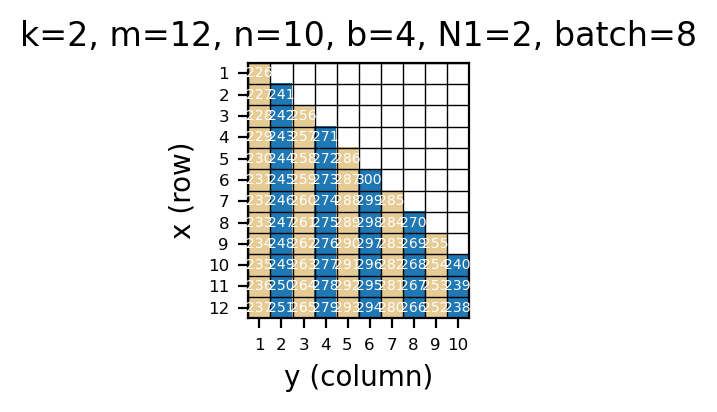

In [9]:
# # 运行示例
# m=12
# n=10
# k=2
# b=4
# N1 =2
# test_calc_batch(k, m, n,b, N1 )

In [10]:
# # 运行示例
# m=11
# n=10
# k=3
# b=5
# N1 =1
# test_calc_batch(k, m, n,b ,N1)